# Smart Waste Classification — ML Pipeline

## Objective

This notebook develops and evaluates machine-learning models for classifying waste images into five categories:

- Glass
- Metal
- Organic
- Paper
- Plastic

The cleaned dataset contains 1,640 usable images after removing exact duplicate samples and contradictory cross-class duplicates.

Two modelling approaches will be investigated:

1. Classical machine learning using HOG image features.
2. A convolutional neural network using TensorFlow.

The models will be evaluated using accuracy, precision, recall, F1-score, and confusion matrices.

In [3]:
%pip install opencv-python
import cv2 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

import keras
from keras import layers

Note: you may need to restart the kernel to use updated packages.


In [4]:
DATA_DIR = Path("../data/raw")

print("Dataset exists:", DATA_DIR.exists())

Dataset exists: True


In [5]:
df = pd.read_csv("../data/clean_dataset.csv")

print("Total images:", len(df))

Total images: 1640


In [6]:
print(df["class"].value_counts())

class
Metal      373
Plastic    335
Paper      320
Glass      312
Organic    300
Name: count, dtype: int64


In [7]:
X = df["filename"].values
y = df["class"].values

In [8]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['Glass' 'Metal' 'Organic' 'Paper' 'Plastic']


## Train, Validation, and Test Split

The cleaned dataset is divided into training, validation, and test sets using stratified sampling.

The split consists of approximately:

- 70% training data
- 15% validation data
- 15% test data

Stratification ensures that the five waste categories remain proportionally represented across each partition.

The test set is kept separate until final model evaluation.

In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    stratify=y_encoded,
    random_state=42
)

In [10]:
X_train.shape

(1148,)

In [11]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [12]:
print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Testing:", len(X_test))

Training: 1148
Validation: 246
Testing: 246


In [13]:
split_distribution = pd.DataFrame({
    "Train": pd.Series(y_train).value_counts(normalize=True),
    "Validation": pd.Series(y_val).value_counts(normalize=True),
    "Test": pd.Series(y_test).value_counts(normalize=True)
})

split_distribution

,Train,Validation,Test
1,0.227352,0.227642,0.227642
4,0.204704,0.203252,0.203252
3,0.195122,0.195122,0.195122
0,0.189895,0.191057,0.191057
2,0.182927,0.182927,0.182927


In [40]:
IMG_SIZE = 224

def preprocess_image(path):
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image

In [41]:
class_name = label_encoder.inverse_transform([y_train[5]])[0]
image_path = DATA_DIR / class_name / X_train[5]

if not image_path.exists():
    raise FileNotFoundError(f"Image not found: {image_path}")

image = preprocess_image(str(image_path))

print("Image shape:", image.shape)
print("Minimum:", image.min())
print("Maximum:", image.max())

Image shape: (224, 224, 3)
Minimum: 0.0
Maximum: 1.0


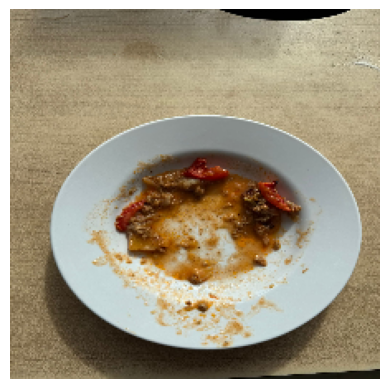

In [42]:
plt.imshow(image)
plt.axis("off")
plt.show()

In [43]:
def load_images(paths):
    images = []

    for path in paths:
        images.append(preprocess_image(path))

    return np.array(images)

In [50]:
images_train = []
images_val = []
images_test = []

for filenames, labels, image_list in [
    (X_train, y_train, images_train),
    (X_val, y_val, images_val),
    (X_test, y_test, images_test)
]:
    paths = [
        str(DATA_DIR / label_encoder.inverse_transform([label])[0] / filename)
        for filename, label in zip(filenames, labels)
    ]
    image_list.extend(load_images(paths))

images_train = np.array(images_train)
images_val = np.array(images_val)
images_test = np.array(images_test)

print("Training images:", images_train.shape)
print("Validation images:", images_val.shape)
print("Testing images:", images_test.shape)

Training images: (1148, 224, 224, 3)
Validation images: (246, 224, 224, 3)
Testing images: (246, 224, 224, 3)


In [58]:
X_train_flat = images_train.reshape(images_train.shape[0], -1)
X_val_flat = images_val.reshape(images_val.shape[0], -1)
X_test_flat = images_test.reshape(images_test.shape[0], -1)

print("Training:", X_train_flat.shape)
print("Validation:", X_val_flat.shape)
print("Testing:", X_test_flat.shape)

Training: (1148, 150528)
Validation: (246, 150528)
Testing: (246, 150528)


## Logistic Regression

Logistic Regression is used as a simple baseline model for waste classification.

In [59]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_flat, y_train)

lr_pred = lr_model.predict(X_test_flat)

In [60]:
from sklearn.metrics import accuracy_score, classification_report

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

print(classification_report(
    y_test,
    lr_pred,
    target_names=label_encoder.classes_
))

Logistic Regression Accuracy: 0.4268292682926829
              precision    recall  f1-score   support

       Glass       0.47      0.40      0.44        47
       Metal       0.31      0.32      0.32        56
     Organic       0.57      0.64      0.60        45
       Paper       0.32      0.35      0.34        48
     Plastic       0.50      0.44      0.47        50

    accuracy                           0.43       246
   macro avg       0.43      0.43      0.43       246
weighted avg       0.43      0.43      0.43       246



## Convolutional Neural Network

A Convolutional Neural Network (CNN) is trained directly on the preprocessed image arrays.

Unlike Logistic Regression, the CNN can learn spatial patterns such as edges, shapes, textures, and object structures from the images.

In [62]:
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Flatten, Dense

In [63]:
cnn_model = Sequential([
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(224, 224, 3)
    ),

    MaxPooling2D(2, 2),

    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D(2, 2),

    Flatten(),

    Dense(128, activation="relu"),

    Dense(5, activation="softmax")
])

c:\Users\Ameera\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [64]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [65]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,908,037 (91.20 MB)

 Trainable params: 23,908,037 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
history = cnn_model.fit(
    X_train_flat.reshape(-1, IMG_SIZE, IMG_SIZE, 3),
    y_train,
    validation_data=(X_val_flat.reshape(-1, IMG_SIZE, IMG_SIZE, 3), y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 351ms/step - accuracy: 0.3049 - loss: 2.7612 - val_accuracy: 0.4065 - val_loss: 1.3560
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 310ms/step - accuracy: 0.4721 - loss: 1.2804 - val_accuracy: 0.4878 - val_loss: 1.2397
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 289ms/step - accuracy: 0.6289 - loss: 0.9641 - val_accuracy: 0.5813 - val_loss: 1.1629
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 288ms/step - accuracy: 0.7883 - loss: 0.6350 - val_accuracy: 0.5163 - val_loss: 1.2403
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 284ms/step - accuracy: 0.8763 - loss: 0.3770 - val_accuracy: 0.5366 - val_loss: 1.5798
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 297ms/step - accuracy: 0.9347 - loss: 0.2288 - val_accuracy: 0.5610 - val_loss: 1.4152
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 286ms/step - accuracy: 0.9573 - loss: 0.1552 - val_accuracy: 0.5650 - val_loss: 1.7929
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 283ms/step - accuracy: 0.9791 - loss: 0.0880 - val_accu

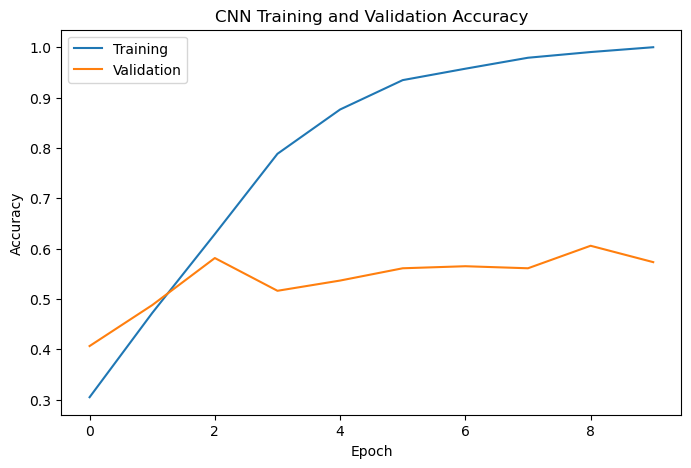

In [72]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training", "Validation"])

plt.show()

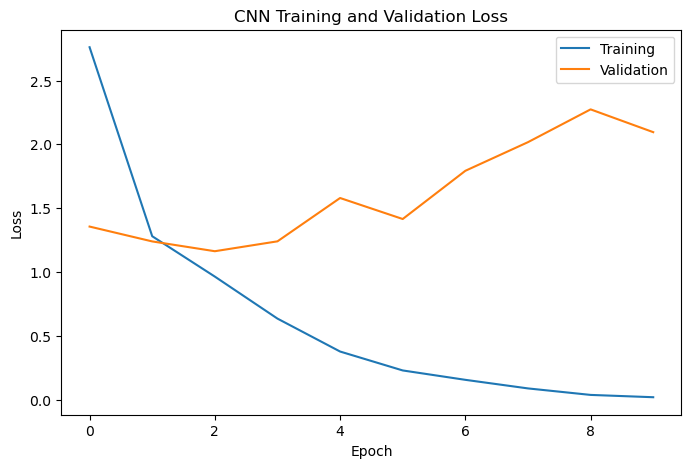

In [75]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Training", "Validation"])

plt.show()

In [76]:
test_loss, test_accuracy = cnn_model.evaluate(
    X_test_flat.reshape(-1, IMG_SIZE, IMG_SIZE, 3),
    y_test
)

print("CNN Test Accuracy:", test_accuracy)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.5285 - loss: 2.3357
CNN Test Accuracy: 0.5284552574157715


In [77]:
cnn_probabilities = cnn_model.predict(X_test_flat.reshape(-1, IMG_SIZE, IMG_SIZE, 3))

cnn_pred = np.argmax(
    cnn_probabilities,
    axis=1
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step


In [79]:
print(classification_report(
    y_test,
    cnn_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

       Glass       0.65      0.47      0.54        47
       Metal       0.44      0.43      0.44        56
     Organic       0.69      0.84      0.76        45
       Paper       0.42      0.42      0.42        48
     Plastic       0.47      0.52      0.50        50

    accuracy                           0.53       246
   macro avg       0.53      0.54      0.53       246
weighted avg       0.53      0.53      0.52       246



In [82]:
svm_model = SVC(kernel="rbf")

svm_model.fit(X_train_flat, y_train)

svm_pred = svm_model.predict(X_test_flat)

In [83]:
svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

print(classification_report(
    y_test,
    svm_pred,
    target_names=label_encoder.classes_
))

SVM Accuracy: 0.6178861788617886
              precision    recall  f1-score   support

       Glass       0.71      0.57      0.64        47
       Metal       0.51      0.59      0.55        56
     Organic       0.65      0.78      0.71        45
       Paper       0.59      0.56      0.57        48
     Plastic       0.70      0.60      0.65        50

    accuracy                           0.62       246
   macro avg       0.63      0.62      0.62       246
weighted avg       0.63      0.62      0.62       246

